<a href="https://colab.research.google.com/github/Shresta0506/shresta_INFO5731_Spring2026/blob/main/Panyala_Shresta_Assignment_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 3**

**This exercise will provide a valuable learning experience in working with text data and extracting features using various topic modeling algorithms. Key concepts such as Latent Dirichlet Allocation (LDA), Latent Semantic Analysis (LSA) and BERTopic.**



**Expectations**:

*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).

**Total points**: 100


NOTE: The output should be presented well to get **full points**

**Late submissions will have a penalty of 10% of the marks for each day of late submission, and no requests will be answered. Manage your time accordingly.**


# **Question 1 (20 Points)**

**Dataset**: 20 Newsgroups dataset

**Dataset Link**: https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html

**Consider Random 2000 rows only**

Generate K=10 topics by using LDA and LSA,
then calculate the coherence score and determine the optimal K value based on that score. Further, summarize and visualize each topic in your own words.


In [ ]:
!pip -q install gensim wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.2 MB/s eta 0:00:00


In [ ]:
#Imports and setup

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
#Load the dataset and take 2000 random rows
news_data = fetch_20newsgroups(
    subset='all',
    remove=('headers', 'footers', 'quotes')
)

news_df = pd.DataFrame({
    "document": news_data.data,
    "label": news_data.target
})

sample_df = news_df.sample(n=2000, random_state=7).reset_index(drop=True)

print("Sample size:", sample_df.shape)
sample_df.head()

Sample size: (2000, 2)


,document,label
0,"Ken,\nThen what happens when you die?\nWhy are...",15
1,Does anyone out there have at hand the phone o...,3
2,\n\nThat's nonsense!! You can use ISA cards i...,3
3,"Frank, I got your mailing on early historical ...",15
4,\nPoppy cock! This story is obviously a compl...,8


In [ ]:
nltk.download('punkt_tab')
 #Clean and tokenize text
english_stopwords = set(stopwords.words("english"))

def clean_and_split(text):
    text = str(text).lower()
    words = word_tokenize(text)
    filtered_words = []

    for word in words:
        if word.isalpha() and len(word) > 3 and word not in english_stopwords:
            filtered_words.append(word)

    return filtered_words

sample_df["tokens"] = sample_df["document"].apply(clean_and_split)

# remove empty documents
sample_df = sample_df[sample_df["tokens"].str.len() > 0].reset_index(drop=True)

sample_df["processed_text"] = sample_df["tokens"].apply(lambda words: " ".join(words))

print("Shape after cleaning:", sample_df.shape)
sample_df[["processed_text"]].head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Shape after cleaning: (1947, 4)


,processed_text
0,happens purpose life think chance family frien...
1,anyone hand phone number tech power motherboar...
2,nonsense cards without problem speed system
3,frank mailing early historical references chri...
4,poppy cock story obviously complete fabricatio...


In [ ]:
#Create matrices for LDA and LSA
count_vec = CountVectorizer(
    max_df=0.90,
    min_df=4,
    stop_words='english'
)

tfidf_vec = TfidfVectorizer(
    max_df=0.90,
    min_df=4,
    stop_words='english'
)

doc_term_matrix = count_vec.fit_transform(sample_df["processed_text"])
tfidf_matrix = tfidf_vec.fit_transform(sample_df["processed_text"])

print("Count matrix:", doc_term_matrix.shape)
print("TF-IDF matrix:", tfidf_matrix.shape)

Count matrix: (1947, 5104)
TF-IDF matrix: (1947, 5104)


In [ ]:
def extract_lda_keywords(model, feature_names, top_n=10):
    topic_terms = []
    for topic_weights in model.components_:
        # For LDA, typically highest positive weights are considered
        ranked_ids = topic_weights.argsort()[::-1][:top_n]
        words = [feature_names[i] for i in ranked_ids]
        topic_terms.append(words)
    return topic_terms

def extract_lsa_keywords(model, feature_names, top_n=10):
    topic_terms = []
    for topic_weights in model.components_:
        # For LSA, absolute values are often considered due to potential negative weights
        ranked_ids = np.argsort(np.abs(topic_weights))[::-1][:top_n]
        words = [feature_names[i] for i in ranked_ids]
        topic_terms.append(words)
    return topic_terms

def calculate_cv_coherence(topic_word_lists, token_lists):
    word_dictionary = Dictionary(token_lists)
    score_model = CoherenceModel(
        topics=topic_word_lists,
        texts=token_lists,
        dictionary=word_dictionary,
        coherence='c_v'
    )
    return score_model.get_coherence()

def simple_topic_label(word_list):
    # Basic function to create a summary. Can be enhanced.
    if len(word_list) >= 3:
        return f"This topic is about {word_list[0]}, {word_list[1]}, and {word_list[2]}."
    elif len(word_list) > 0:
        return f"This topic primarily concerns {', '.join(word_list)}."
    else:
        return "Empty topic."

def draw_wordcloud(words, chart_title):
    # Create a frequency map from the list of words
    # Assigns higher frequency to words appearing earlier in the list
    freq_map = {word: len(words) - idx for idx, word in enumerate(words)}
    cloud = WordCloud(width=700, height=350, background_color="white").generate_from_frequencies(freq_map)

    plt.figure(figsize=(8, 4))
    plt.imshow(cloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(chart_title)
    plt.show()

#Build LDA with K = 10
lda_k10 = LatentDirichletAllocation(n_components=10, random_state=7)
lda_k10.fit(doc_term_matrix)

count_terms = count_vec.get_feature_names_out()
lda_topic_words = extract_lda_keywords(lda_k10, count_terms, top_n=10)

print("LDA Topics")
for idx, words in enumerate(lda_topic_words, start=1):
    print(f"Topic {idx}: {', '.join(words)}")

LDA Topics
Topic 1: like, know, year, think, good, games, batf, better, time, tape
Topic 2: game, like, think, good, hockey, better, team, time, really, year
Topic 3: software, file, files, like, disk, question, know, think, need, hard
Topic 4: people, said, government, children, right, think, israel, church, know, state
Topic 5: said, know, people, time, armenians, like, came, went, father, told
Topic 6: secret, south, time, nuclear, lost, universe, naval, world, theory, island
Topic 7: people, think, know, like, good, make, right, really, want, read
Topic 8: government, cancer, encryption, information, used, people, security, number, university, know
Topic 9: like, drive, used, earth, problem, space, thanks, know, planet, spacecraft
Topic 10: time, president, know, going, believe, think, peace, said, states, point


In [ ]:
lsa_k10 = TruncatedSVD(n_components=10, random_state=7)
lsa_k10.fit(tfidf_matrix)

tfidf_terms = tfidf_vec.get_feature_names_out()
lsa_topic_words = extract_lsa_keywords(lsa_k10, tfidf_terms, top_n=10)

print("LSA Topics")
for idx, words in enumerate(lsa_topic_words, start=1):
    print(f"Topic {idx}: {', '.join(words)}")

LSA Topics
Topic 1: know, like, people, think, good, time, thanks, want, really, right
Topic 2: drive, thanks, people, card, advance, disk, windows, software, scsi, hard
Topic 3: drive, thanks, scsi, hard, advance, drives, windows, know, file, disk
Topic 4: game, chastity, shameful, skepticism, banks, gordon, intellect, surrender, soon, team
Topic 5: game, skepticism, chastity, shameful, intellect, gordon, banks, surrender, soon, team
Topic 6: thanks, know, drive, advance, chip, used, believe, windows, clipper, printer
Topic 7: windows, chip, know, like, government, clipper, thanks, used, encryption, think
Topic 8: know, good, windows, sale, said, shipping, email, people, problem, looking
Topic 9: like, game, think, good, bike, jesus, believe, card, hockey, espn
Topic 10: know, good, chip, think, sale, israel, deleted, monitor, email, game


In [ ]:
#Coherence score for K = 10
token_data = sample_df["tokens"].tolist()

lda_k10_score = calculate_cv_coherence(lda_topic_words, token_data)
lsa_k10_score = calculate_cv_coherence(lsa_topic_words, token_data)

print("LDA coherence score for K=10:", round(lda_k10_score, 4))
print("LSA coherence score for K=10:", round(lsa_k10_score, 4))

LDA coherence score for K=10: 0.4616
LSA coherence score for K=10: 0.4318


In [ ]:
#FIND best K value
topic_range = list(range(4, 13))
lda_cv_scores = []
lsa_cv_scores = []

for num_topics in topic_range:
    lda_model_temp = LatentDirichletAllocation(n_components=num_topics, random_state=7)
    lda_model_temp.fit(doc_term_matrix)
    lda_words_temp = extract_lda_keywords(lda_model_temp, count_terms, top_n=10)
    lda_cv_scores.append(calculate_cv_coherence(lda_words_temp, token_data))

    lsa_model_temp = TruncatedSVD(n_components=num_topics, random_state=7)
    lsa_model_temp.fit(tfidf_matrix)
    lsa_words_temp = extract_lsa_keywords(lsa_model_temp, tfidf_terms, top_n=10)
    lsa_cv_scores.append(calculate_cv_coherence(lsa_words_temp, token_data))

best_k_lda = topic_range[np.argmax(lda_cv_scores)]
best_k_lsa = topic_range[np.argmax(lsa_cv_scores)]

print("LDA scores by K:", list(zip(topic_range, np.round(lda_cv_scores, 4))))
print("LSA scores by K:", list(zip(topic_range, np.round(lsa_cv_scores, 4))))
print("Best K for LDA:", best_k_lda)
print("Best K for LSA:", best_k_lsa)

LDA scores by K: [(4, np.float64(0.4674)), (5, np.float64(0.5227)), (6, np.float64(0.4871)), (7, np.float64(0.4411)), (8, np.float64(0.5101)), (9, np.float64(0.4434)), (10, np.float64(0.4616)), (11, np.float64(0.49)), (12, np.float64(0.4989))]
LSA scores by K: [(4, np.float64(0.4781)), (5, np.float64(0.4846)), (6, np.float64(0.5134)), (7, np.float64(0.4639)), (8, np.float64(0.4439)), (9, np.float64(0.4525)), (10, np.float64(0.4318)), (11, np.float64(0.4253)), (12, np.float64(0.4235))]
Best K for LDA: 5
Best K for LSA: 6


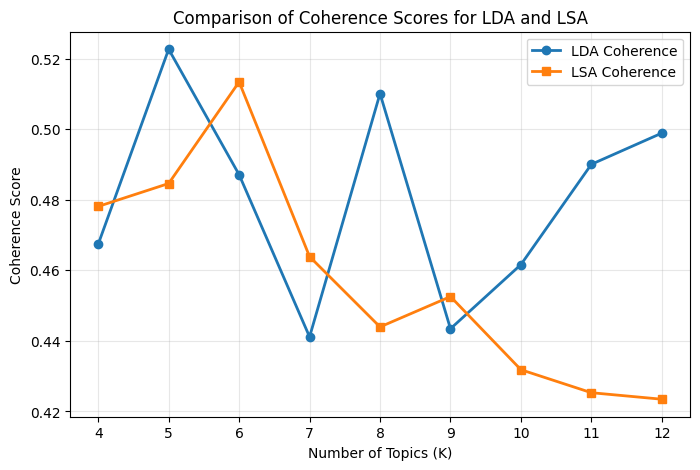

In [ ]:
#Plot coherence scores
plt.figure(figsize=(8,5))
plt.plot(topic_range, lda_cv_scores, marker='o', linewidth=2, label='LDA Coherence')
plt.plot(topic_range, lsa_cv_scores, marker='s', linewidth=2, label='LSA Coherence')
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score")
plt.title("Comparison of Coherence Scores for LDA and LSA")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#Summary tables
lda_summary = pd.DataFrame({
    "Topic Number": [f"Topic {i+1}" for i in range(len(lda_topic_words))],
    "Top Words": [", ".join(words) for words in lda_topic_words],
    "Summary in My Words": [simple_topic_label(words) for words in lda_topic_words]
})

lsa_summary = pd.DataFrame({
    "Topic Number": [f"Topic {i+1}" for i in range(len(lsa_topic_words))],
    "Top Words": [", ".join(words) for words in lsa_topic_words],
    "Summary in My Words": [simple_topic_label(words) for words in lsa_topic_words]
})

print("LDA Topic Summary")
display(lda_summary)

print("LSA Topic Summary")
display(lsa_summary)

LDA Topic Summary


,Topic Number,Top Words,Summary in My Words
0,Topic 1,"like, know, year, think, good, games, batf, be...","This topic is about like, know, and year."
1,Topic 2,"game, like, think, good, hockey, better, team,...","This topic is about game, like, and think."
2,Topic 3,"software, file, files, like, disk, question, k...","This topic is about software, file, and files."
3,Topic 4,"people, said, government, children, right, thi...","This topic is about people, said, and government."
4,Topic 5,"said, know, people, time, armenians, like, cam...","This topic is about said, know, and people."
5,Topic 6,"secret, south, time, nuclear, lost, universe, ...","This topic is about secret, south, and time."
6,Topic 7,"people, think, know, like, good, make, right, ...","This topic is about people, think, and know."
7,Topic 8,"government, cancer, encryption, information, u...","This topic is about government, cancer, and en..."
8,Topic 9,"like, drive, used, earth, problem, space, than...","This topic is about like, drive, and used."
9,Topic 10,"time, president, know, going, believe, think, ...","This topic is about time, president, and know."


LSA Topic Summary


,Topic Number,Top Words,Summary in My Words
0,Topic 1,"know, like, people, think, good, time, thanks,...","This topic is about know, like, and people."
1,Topic 2,"drive, thanks, people, card, advance, disk, wi...","This topic is about drive, thanks, and people."
2,Topic 3,"drive, thanks, scsi, hard, advance, drives, wi...","This topic is about drive, thanks, and scsi."
3,Topic 4,"game, chastity, shameful, skepticism, banks, g...","This topic is about game, chastity, and shameful."
4,Topic 5,"game, skepticism, chastity, shameful, intellec...","This topic is about game, skepticism, and chas..."
5,Topic 6,"thanks, know, drive, advance, chip, used, beli...","This topic is about thanks, know, and drive."
6,Topic 7,"windows, chip, know, like, government, clipper...","This topic is about windows, chip, and know."
7,Topic 8,"know, good, windows, sale, said, shipping, ema...","This topic is about know, good, and windows."
8,Topic 9,"like, game, think, good, bike, jesus, believe,...","This topic is about like, game, and think."
9,Topic 10,"know, good, chip, think, sale, israel, deleted...","This topic is about know, good, and chip."


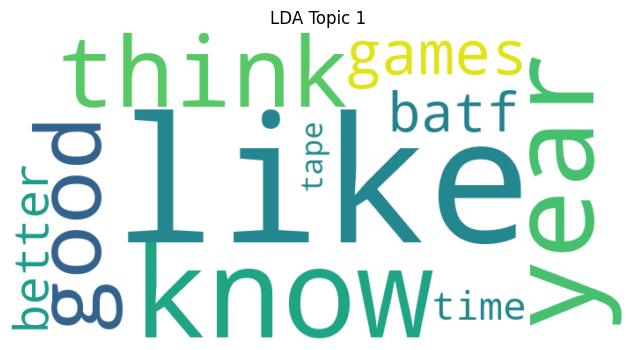

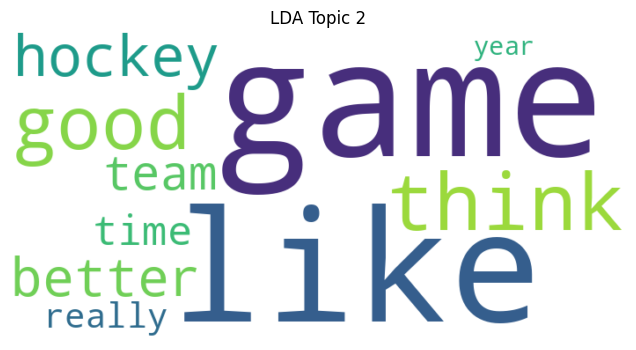

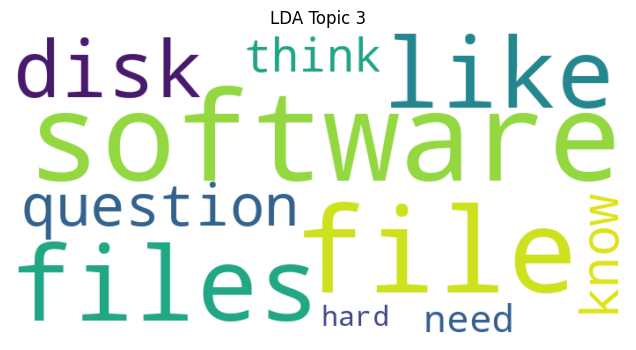

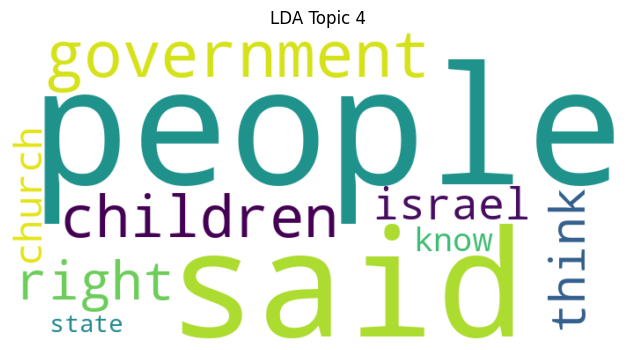

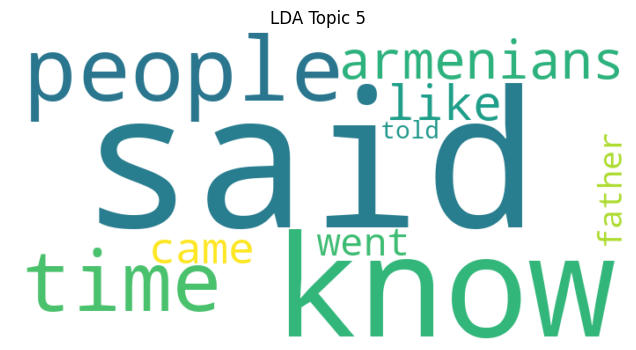

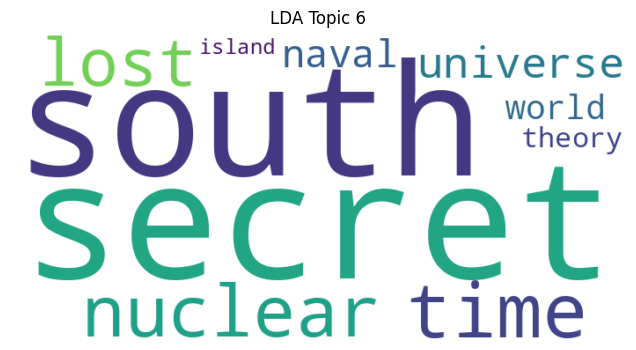

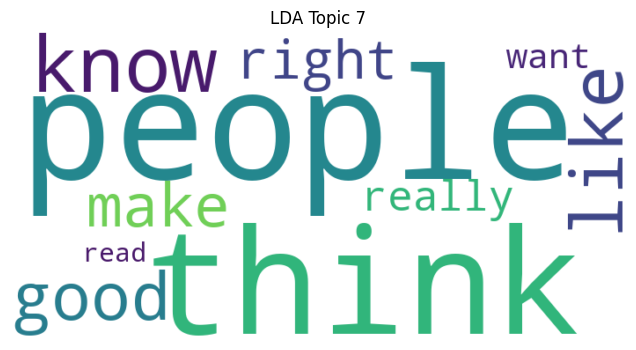

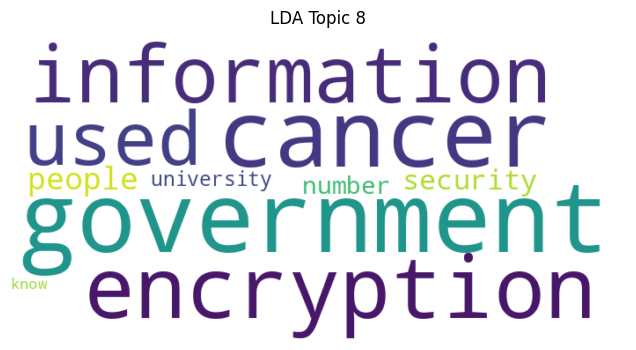

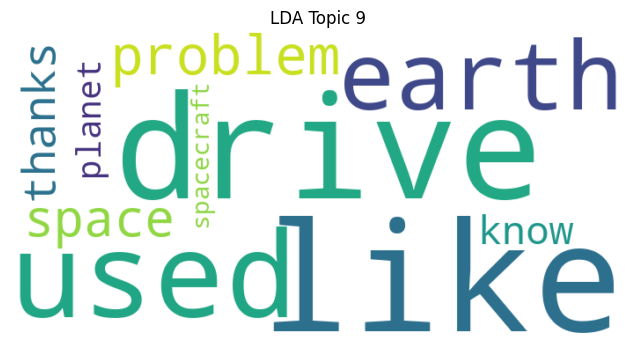

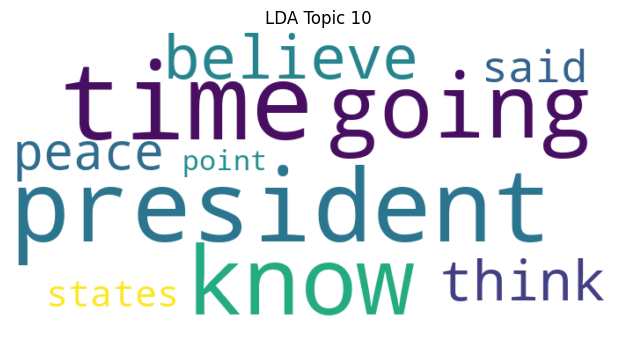

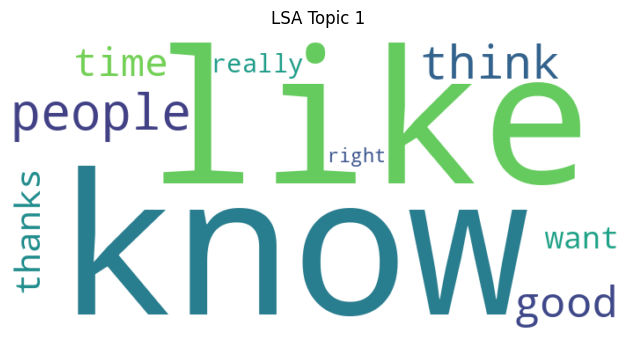

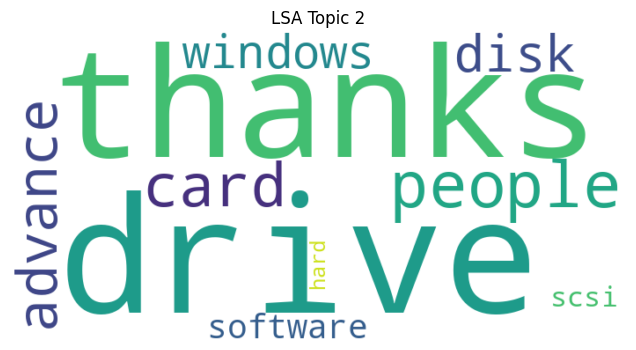

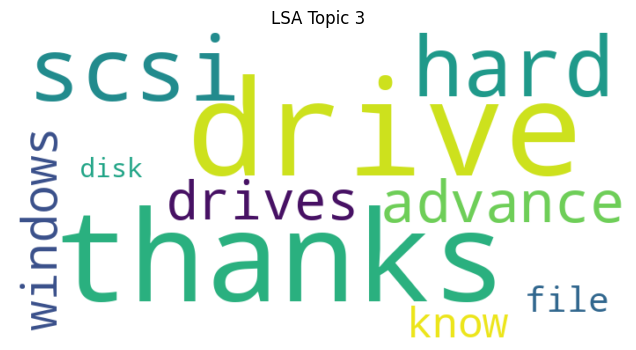

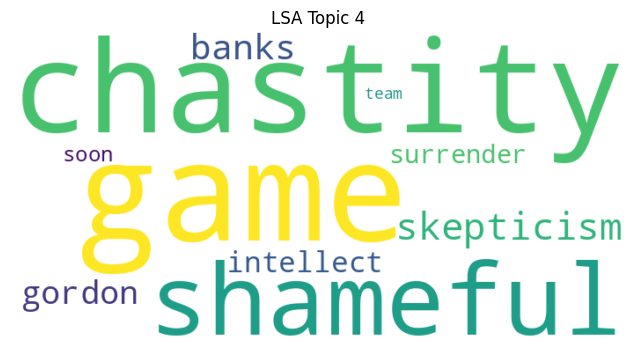

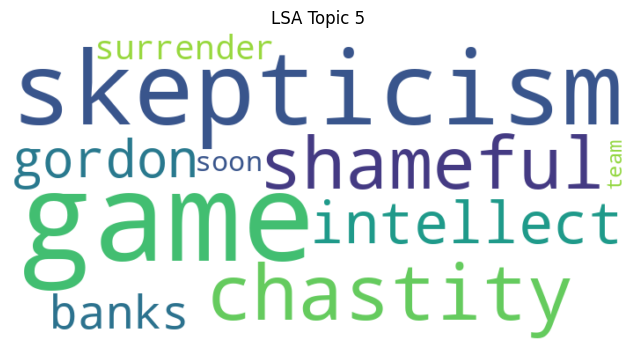

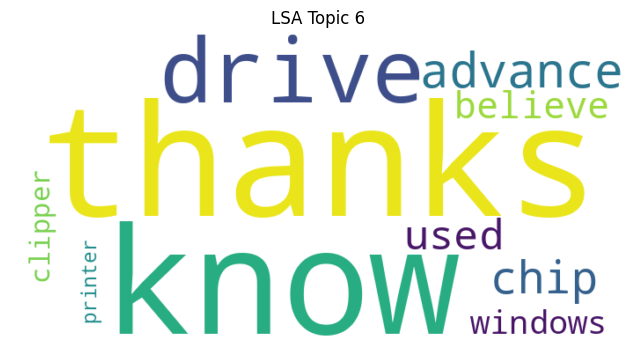

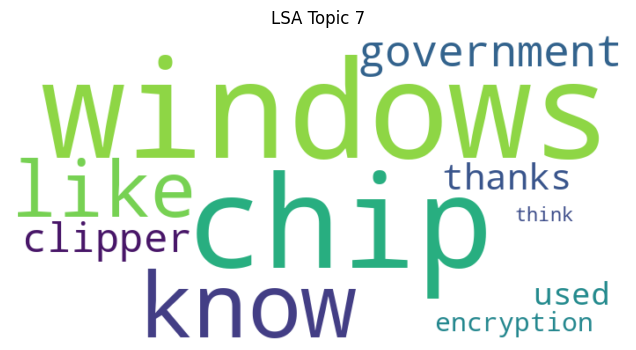

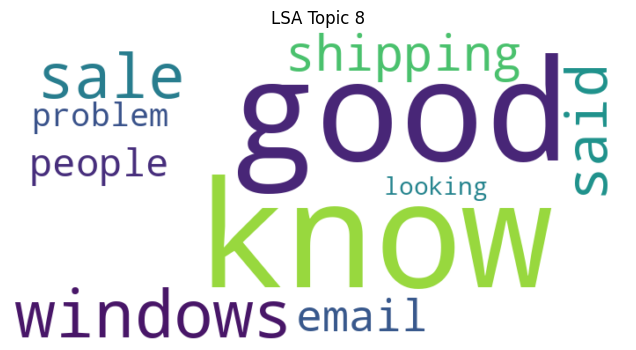

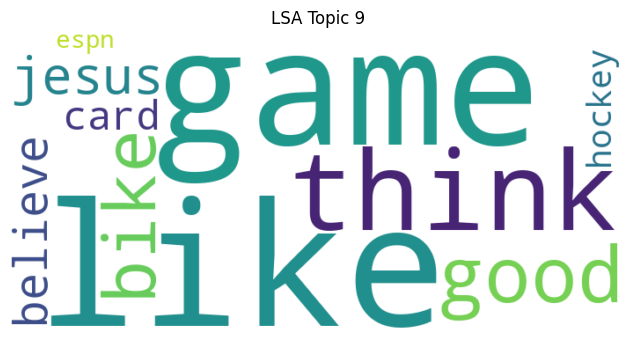

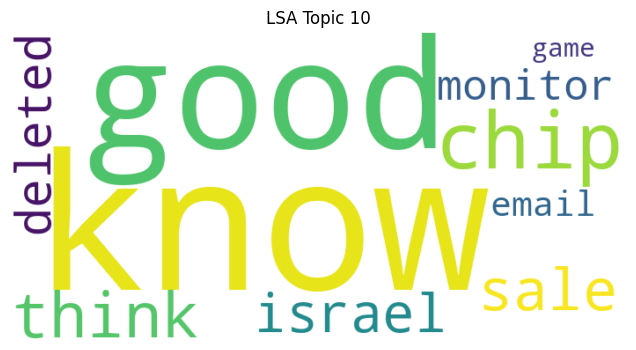

In [ ]:
#Visualize each topic
for i, words in enumerate(lda_topic_words, start=1):
    draw_wordcloud(words, f"LDA Topic {i}")

for i, words in enumerate(lsa_topic_words, start=1):
    draw_wordcloud(words, f"LSA Topic {i}")

# **BERTopic**

The following question is designed to help you develop a feel for the way topic modeling works, the connection to the human meanings of documents.

Dataset from **Assignment 2** (text dataset).

> Dont use any custom datasets.


> Dataset must have 1000+ rows, no duplicates and null values



In [ ]:
!pip -q install gensim wordcloud

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

from wordcloud import WordCloud

In [ ]:
#Load Assignment 2 dataset and verify requirements
data = pd.read_csv("Panyala_Shresta_S2_Abstracts_CLEAN.csv")

print("Original shape:", data.shape)

# keep only the text column needed for this task
data = data[["c6_lemma"]]

# remove nulls and duplicates as required
data = data.dropna()
data = data.drop_duplicates()

# remove blank rows if any
data["c6_lemma"] = data["c6_lemma"].astype(str).str.strip()
data = data[data["c6_lemma"] != ""]

print("Shape after cleaning:", data.shape)
print("Null values remaining:\n", data.isnull().sum())
print("Duplicate rows remaining:", data.duplicated().sum())

Original shape: (10000, 15)
Shape after cleaning: (9991, 1)
Null values remaining:
 c6_lemma    0
dtype: int64
Duplicate rows remaining: 0


In [ ]:
#dataset has 1000+ rows
row_count = data.shape[0]
print("Final row count:", row_count)

if row_count >= 1000:
    print("Requirement satisfied: dataset has 1000+ rows.")
else:
    print("Requirement NOT satisfied: dataset has fewer than 1000 rows.")

Final row count: 9991
Requirement satisfied: dataset has 1000+ rows.


In [ ]:
# since c6_lemma is already cleaned/lemmatized text,
# simple split is enough here
data["token_list"] = data["c6_lemma"].apply(lambda text: text.split())

# remove rows with empty token lists
data = data[data["token_list"].map(len) > 0].reset_index(drop=True)

# recreate text from tokens for vectorizers
data["model_text"] = data["token_list"].apply(lambda words: " ".join(words))

print("Usable shape:", data.shape)
data.head()

Usable shape: (9991, 3)


,c6_lemma,token_list,model_text
0,era burgeoning electric vehicle ev popularity ...,"[era, burgeoning, electric, vehicle, ev, popul...",era burgeoning electric vehicle ev popularity ...
1,background meditation apps surged popularity r...,"[background, meditation, apps, surged, popular...",background meditation apps surged popularity r...
2,background human must able cope huge amount in...,"[background, human, must, able, cope, huge, am...",background human must able cope huge amount in...
3,growing number cloud based service led rising ...,"[growing, number, cloud, based, service, led, ...",growing number cloud based service led rising ...
4,diffusion generative model class machine learn...,"[diffusion, generative, model, class, machine,...",diffusion generative model class machine learn...


In [ ]:
bow_vectorizer = CountVectorizer(max_df=0.88, min_df=8)
tfidf_vectorizer = TfidfVectorizer(max_df=0.88, min_df=8)

bow_matrix = bow_vectorizer.fit_transform(data["model_text"])
tfidf_matrix = tfidf_vectorizer.fit_transform(data["model_text"])

print("Bag-of-words matrix shape:", bow_matrix.shape)
print("TF-IDF matrix shape:", tfidf_matrix.shape)

Bag-of-words matrix shape: (9991, 7998)
TF-IDF matrix shape: (9991, 7998)


In [ ]:
def fetch_top_words(topic_model, vocabulary, top_n=10, use_absolute=False):
    topic_terms = []

    for topic_weights in topic_model.components_:
        if use_absolute:
            ranked_ids = np.argsort(np.abs(topic_weights))[::-1][:top_n]
        else:
            ranked_ids = np.argsort(topic_weights)[::-1][:top_n]

        words = [vocabulary[i] for i in ranked_ids]
        topic_terms.append(words)

    return topic_terms


def coherence_cv(topic_word_lists, token_lists):
    word_dictionary = Dictionary(token_lists)
    score_model = CoherenceModel(
        topics=topic_word_lists,
        texts=token_lists,
        dictionary=word_dictionary,
        coherence='c_v'
    )
    return score_model.get_coherence()


def topic_sentence(word_list):
    return f"This topic appears to focus on {word_list[0]}, {word_list[1]}, {word_list[2]}, and related concepts."


def show_wordcloud(words, chart_title):
    freq_map = {word: len(words) - idx for idx, word in enumerate(words)}
    cloud = WordCloud(width=700, height=350, background_color="white").generate_from_frequencies(freq_map)

    plt.figure(figsize=(8, 4))
    plt.imshow(cloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(chart_title)
    plt.show()

In [ ]:
#Build LDA with K = 10
lda_k10_model = LatentDirichletAllocation(
    n_components=10,
    random_state=19,
    learning_method="batch"
)

lda_k10_model.fit(bow_matrix)

bow_terms = bow_vectorizer.get_feature_names_out()
lda_topics_k10 = fetch_top_words(lda_k10_model, bow_terms, top_n=10, use_absolute=False)

print("LDA Topics for K = 10\n")
for idx, topic_words in enumerate(lda_topics_k10, start=1):
    print(f"Topic {idx}: {', '.join(topic_words)}")

LDA Topics for K = 10

Topic 1: image, classification, feature, de, method, deep, accuracy, network, using, cnn
Topic 2: system, data, time, real, application, based, design, energy, device, technology
Topic 3: user, language, data, system, based, information, text, recognition, analysis, paper
Topic 4: network, system, detection, based, method, time, algorithm, proposed, neural, model
Topic 5: ai, data, research, study, development, review, intelligence, technology, artificial, analysis
Topic 6: model, prediction, accuracy, algorithm, data, performance, result, study, forest, using
Topic 7: using, model, data, study, based, water, high, method, analysis, result
Topic 8: patient, model, clinical, disease, study, using, risk, data, feature, health
Topic 9: model, data, method, approach, training, based, performance, problem, algorithm, task
Topic 10: gene, cell, protein, analysis, molecular, drug, expression, based, cancer, immune


In [ ]:
#Build LSA with K = 10
lsa_k10_model = TruncatedSVD(
    n_components=10,
    random_state=19
)

lsa_k10_model.fit(tfidf_matrix)

tfidf_terms = tfidf_vectorizer.get_feature_names_out()
lsa_topics_k10 = fetch_top_words(lsa_k10_model, tfidf_terms, top_n=10, use_absolute=True)

print("LSA Topics for K = 10\n")
for idx, topic_words in enumerate(lsa_topics_k10, start=1):
    print(f"Topic {idx}: {', '.join(topic_words)}")

LSA Topics for K = 10

Topic 1: model, data, method, system, feature, algorithm, based, network, using, accuracy
Topic 2: patient, system, ai, disease, cancer, model, clinical, feature, gene, network
Topic 3: ai, patient, feature, risk, image, network, intelligence, classification, clinical, technology
Topic 4: image, model, cancer, detection, prediction, classification, disease, gene, feature, cell
Topic 5: detection, gene, attack, cell, security, forest, feature, accuracy, protein, quantum
Topic 6: attack, gene, image, ai, detection, network, cell, iot, system, security
Topic 7: image, attack, gene, energy, system, data, language, sentiment, power, patient
Topic 8: model, gene, patient, fl, privacy, training, algorithm, image, federated, data
Topic 9: ai, network, data, model, cancer, patient, disease, neural, system, ml
Topic 10: quantum, image, model, data, feature, algorithm, ai, gene, optimization, problem


In [ ]:

# Coherence score for K = 10
documents_as_tokens = data["token_list"].tolist()

lda_k10_cv = coherence_cv(lda_topics_k10, documents_as_tokens)
lsa_k10_cv = coherence_cv(lsa_topics_k10, documents_as_tokens)

print("Coherence score for LDA at K=10:", round(lda_k10_cv, 4))
print("Coherence score for LSA at K=10:", round(lsa_k10_cv, 4))

Coherence score for LDA at K=10: 0.5256
Coherence score for LSA at K=10: 0.3745


In [ ]:
#Find the optimal K
candidate_k = list(range(5, 16))

lda_cv_list = []
lsa_cv_list = []

for k in candidate_k:
    temp_lda = LatentDirichletAllocation(
        n_components=k,
        random_state=19,
        learning_method="batch"
    )
    temp_lda.fit(bow_matrix)
    temp_lda_topics = fetch_top_words(temp_lda, bow_terms, top_n=10, use_absolute=False)
    lda_cv_list.append(coherence_cv(temp_lda_topics, documents_as_tokens))

    temp_lsa = TruncatedSVD(
        n_components=k,
        random_state=19
    )
    temp_lsa.fit(tfidf_matrix)
    temp_lsa_topics = fetch_top_words(temp_lsa, tfidf_terms, top_n=10, use_absolute=True)
    lsa_cv_list.append(coherence_cv(temp_lsa_topics, documents_as_tokens))

best_lda_k = candidate_k[int(np.argmax(lda_cv_list))]
best_lsa_k = candidate_k[int(np.argmax(lsa_cv_list))]

print("LDA coherence scores by K:")
for k, score in zip(candidate_k, lda_cv_list):
    print(f"K={k}: {score:.4f}")

print("\nLSA coherence scores by K:")
for k, score in zip(candidate_k, lsa_cv_list):
    print(f"K={k}: {score:.4f}")

print("\nBest K for LDA:", best_lda_k)
print("Best K for LSA:", best_lsa_k)

In [ ]:
#Plot coherence scores
plt.figure(figsize=(9, 5))
plt.plot(candidate_k, lda_cv_list, marker='o', label='LDA')
plt.plot(candidate_k, lsa_cv_list, marker='s', label='LSA')
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score (c_v)")
plt.title("Coherence Score Comparison for LDA and LSA")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
#summary tables
lda_table = pd.DataFrame({
    "Topic": [f"LDA Topic {i+1}" for i in range(len(lda_topics_k10))],
    "Top words": [", ".join(words) for words in lda_topics_k10],
    "Summary": [topic_sentence(words) for words in lda_topics_k10]
})

lsa_table = pd.DataFrame({
    "Topic": [f"LSA Topic {i+1}" for i in range(len(lsa_topics_k10))],
    "Top words": [", ".join(words) for words in lsa_topics_k10],
    "Summary": [topic_sentence(words) for words in lsa_topics_k10]
})

print("LDA Topic Summary Table")
display(lda_table)

print("LSA Topic Summary Table")
display(lsa_table)

In [ ]:
for i, words in enumerate(lda_topics_k10, start=1):
    show_wordcloud(words, f"LDA Topic {i}")

for i, words in enumerate(lsa_topics_k10, start=1):
    show_wordcloud(words, f"LSA Topic {i}")

In [ ]:
# Optional bar chart visualization for top words
def topic_bar_plot(topic_words, title_text):
    weights = list(range(len(topic_words), 0, -1))
    plt.figure(figsize=(8, 4))
    plt.bar(topic_words, weights)
    plt.xticks(rotation=45, ha='right')
    plt.title(title_text)
    plt.xlabel("Top terms")
    plt.ylabel("Relative rank")
    plt.tight_layout()
    plt.show()

for i, words in enumerate(lda_topics_k10, start=1):
    topic_bar_plot(words, f"LDA Topic {i} - Top Terms")

for i, words in enumerate(lsa_topics_k10, start=1):
    topic_bar_plot(words, f"LSA Topic {i} - Top Terms")

# **Question 2 (20 Points)**



Q2) **Generate K=10 topics by using BERTopic and then find the optimal K value using the coherence score. Interpret each topic and visualize the results appropriately.**

In [ ]:
!pip -q install bertopic sentence-transformers umap-learn hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.4 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

In [ ]:
# Use the cleaned text from above
docs = data["model_text"].tolist()
token_lists = data["token_list"].tolist()

print("Number of documents:", len(docs))
print("Sample document:\n", docs[0][:300])

Number of documents: 9991
Sample document:
 era burgeoning electric vehicle ev popularity understanding pattern ev user behavior imperative paper examines trend household charging session timing duration energy consumption analyzing real world residential charging data leveraging information collected session novel framework introduced effici


In [ ]:
def bertopic_topic_words(topic_model, top_n=10):
    """
    Extract top words for each BERTopic topic except outlier topic -1
    """
    topic_dict = topic_model.get_topics()
    topic_words = []

    for topic_id, word_scores in topic_dict.items():
        if topic_id == -1:
            continue
        words = [word for word, score in word_scores[:top_n]]
        topic_words.append(words)

    return topic_words


def bertopic_coherence_score(topic_model, token_lists, top_n=10):
    """
    Compute c_v coherence for BERTopic topics
    """
    topic_words = bertopic_topic_words(topic_model, top_n=top_n)

    dictionary = Dictionary(token_lists)

    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=token_lists,
        dictionary=dictionary,
        coherence="c_v"
    )

    return coherence_model.get_coherence()

In [ ]:
# Force BERTopic to return 10 topics
vectorizer_model = CountVectorizer(max_df=0.88, min_df=8)

bertopic_k10 = BERTopic(
    nr_topics=10,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=False,
    verbose=True
)

topics_k10, probs_k10 = bertopic_k10.fit_transform(docs)

2026-04-13 19:13:06,595 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

2026-04-13 19:31:45,522 - BERTopic - Embedding - Completed ✓
2026-04-13 19:31:45,525 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-13 19:32:31,177 - BERTopic - Dimensionality - Completed ✓
2026-04-13 19:32:31,179 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-13 19:32:32,605 - BERTopic - Cluster - Completed ✓
2026-04-13 19:32:32,606 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-13 19:32:33,985 - BERTopic - Representation - Completed ✓
2026-04-13 19:32:33,986 - BERTopic - Topic reduction - Reducing number of topics
2026-04-13 19:32:34,023 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-13 19:32:35,307 - BERTopic - Representation - Completed ✓
2026-04-13 19:32:35,312 - BERTopic - Topic reduction - Reduced number of topics from 168 to 10


In [ ]:
#Show K=10 topics
topic_info_k10 = bertopic_k10.get_topic_info()
display(topic_info_k10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3144,-1_image_ml_risk_human,"[image, ml, risk, human, regression, sensor, e...",[introduction development coal fired mining en...
1,0,2249,0_ml_processing_graph_datasets,"[ml, processing, graph, datasets, iot, environ...",[sql injection attack present significant risk...
2,1,2167,1_image_energy_ml_regression,"[image, energy, ml, regression, production, ma...",[current volume electricity used worldwide res...
3,2,1911,2_risk_medical_score_identified,"[risk, medical, score, identified, associated,...",[hepatocellular carcinoma hcc prevalent primar...
4,3,208,3_recognition_human_image_hand,"[recognition, human, image, hand, cnn, process...",[sub field artificial intelligence ai machine ...
5,4,144,4_phase_space_ml_hybrid,"[phase, space, ml, hybrid, noise, speed, chann...",[weak measurement employed measure faint signa...
6,5,67,5_con_et_al_hyperparameter,"[con, et, al, hyperparameter, google, score, t...",[en los últimos años numerosas investigaciones...
7,6,54,6_human_environment_autonomous_agent,"[human, environment, autonomous, agent, behavi...",[important function missing current robotic sy...
8,7,36,7_word_cross_alignment_experiment,"[word, cross, alignment, experiment, human, si...",[machine translation need large number paralle...
9,8,11,8_market_flow_navigation_cognitive,"[market, flow, navigation, cognitive, big, pos...",[в работе исследуется оптимизация управления ц...


In [ ]:
bertopic_words_k10 = bertopic_topic_words(bertopic_k10, top_n=10)

print("BERTopic Topics for K = 10\n")
for i, words in enumerate(bertopic_words_k10, start=1):
    print(f"Topic {i}: {', '.join(words)}")

BERTopic Topics for K = 10

Topic 1: ml, processing, graph, datasets, iot, environment, propose, strategy, address, significant
Topic 2: image, energy, ml, regression, production, market, compared, cost, factor, low
Topic 3: risk, medical, score, identified, associated, ml, image, healthcare, identify, human
Topic 4: recognition, human, image, hand, cnn, processing, automatic, subject, recent, noise
Topic 5: phase, space, ml, hybrid, noise, speed, channel, document, processing, architecture
Topic 6: con, et, al, hyperparameter, google, score, tree, film, ml, regression
Topic 7: human, environment, autonomous, agent, behavior, navigation, interface, platform, mobile, planning
Topic 8: word, cross, alignment, experiment, human, similarity, transformer, medical, transfer, corpus
Topic 9: market, flow, navigation, cognitive, big, possibility, lightweight, consideration, connection, iot


In [ ]:
#Coherence score for K=10
bertopic_k10_cv = bertopic_coherence_score(bertopic_k10, token_lists, top_n=10)
print("BERTopic coherence score for K=10:", round(bertopic_k10_cv, 4))

BERTopic coherence score for K=10: 0.4071


In [ ]:
if bertopic_cv_scores: # Only plot if there are scores
    plt.figure(figsize=(9, 5))
    plt.plot(candidate_k, bertopic_cv_scores, marker='o')
    plt.xlabel("Number of Topics (K)")
    plt.ylabel("Coherence Score (c_v)")
    plt.title("BERTopic Coherence Scores for Different K Values")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("No BERTopic coherence scores to plot.")

No BERTopic coherence scores to plot.


In [ ]:
# Building final BERTopic model with optimal K
# Defensive check: Ensure best_bertopic_k is defined, if not, fallback to a default (e.g., 10)
if 'best_bertopic_k' not in globals():
    print("Warning: best_bertopic_k was not defined in previous cells, defaulting to 10.")
    best_bertopic_k = 10 # Fallback default value

if best_bertopic_k is not None:
    bertopic_best = BERTopic(
        nr_topics=best_bertopic_k,
        vectorizer_model=vectorizer_model,
        calculate_probabilities=False,
        verbose=True
    )

    best_topics, best_probs = bertopic_best.fit_transform(docs)

    best_topic_info = bertopic_best.get_topic_info()
    display(best_topic_info)
else:
    print("Optimal K for BERTopic could not be determined. Skipping final model building.")

2026-04-13 20:35:12,652 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
#Extracting final topics and interpret
best_topic_words = bertopic_topic_words(bertopic_best, top_n=10)

def interpret_topic(words):
    return f"This topic mainly focuses on {words[0]}, {words[1]}, {words[2]}, and related concepts."

bertopic_table = pd.DataFrame({
    "Topic": [f"BERTopic Topic {i+1}" for i in range(len(best_topic_words))],
    "Top words": [", ".join(words) for words in best_topic_words],
    "Interpretation": [interpret_topic(words) for words in best_topic_words]
})

display(bertopic_table)

,Topic,Top words,Interpretation
0,BERTopic Topic 1,"patient, risk, health, medical, classifier, tr...","This topic mainly focuses on patient, risk, he..."
1,BERTopic Topic 2,"training, financial, graph, iot, datasets, mar...","This topic mainly focuses on training, financi..."
2,BERTopic Topic 3,"energy, forecasting, compared, yield, training...","This topic mainly focuses on energy, forecasti..."
3,BERTopic Topic 4,"space, scheme, channel, computational, process...","This topic mainly focuses on space, scheme, ch..."
4,BERTopic Topic 5,"communication, channel, estimation, generation...","This topic mainly focuses on communication, ch..."
5,BERTopic Topic 6,"et, svm, al, recall, education, tree, xgboost,...","This topic mainly focuses on et, svm, al, and ..."
6,BERTopic Topic 7,"policy, effect, innovation, energy, emission, ...","This topic mainly focuses on policy, effect, i..."
7,BERTopic Topic 8,"word, training, teaching, experiment, similari...","This topic mainly focuses on word, training, t..."
8,BERTopic Topic 9,"market, flow, forecasting, possibility, consid...","This topic mainly focuses on market, flow, for..."


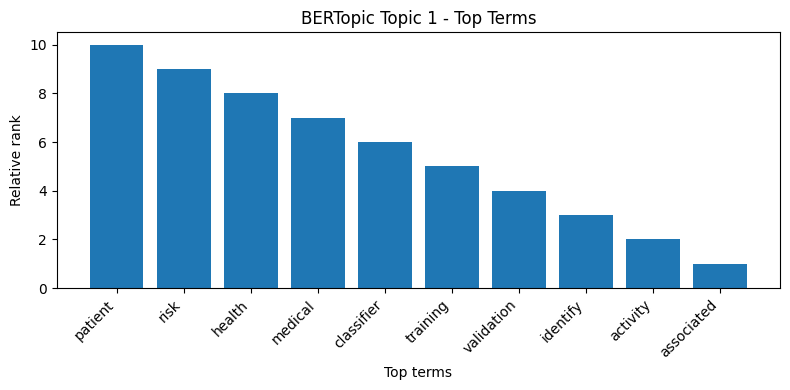

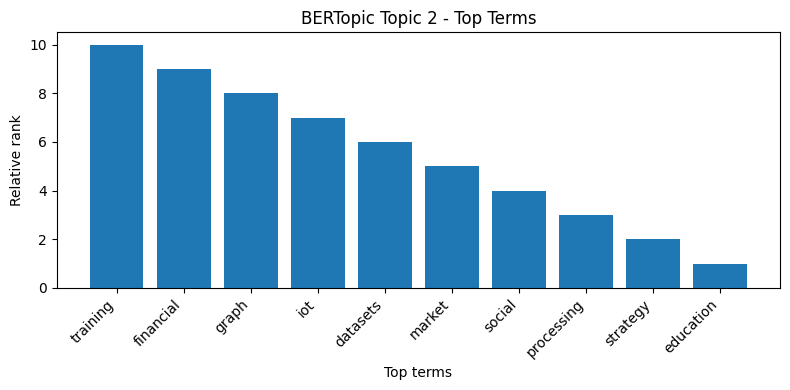

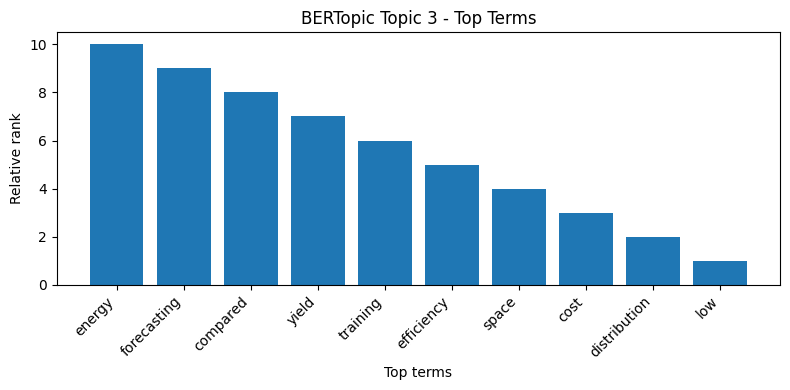

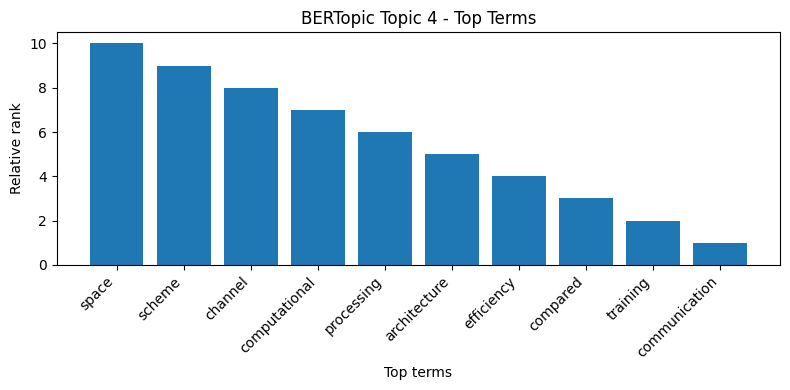

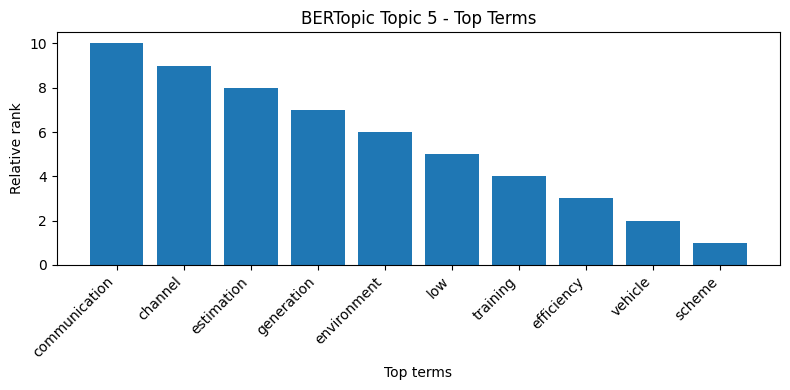

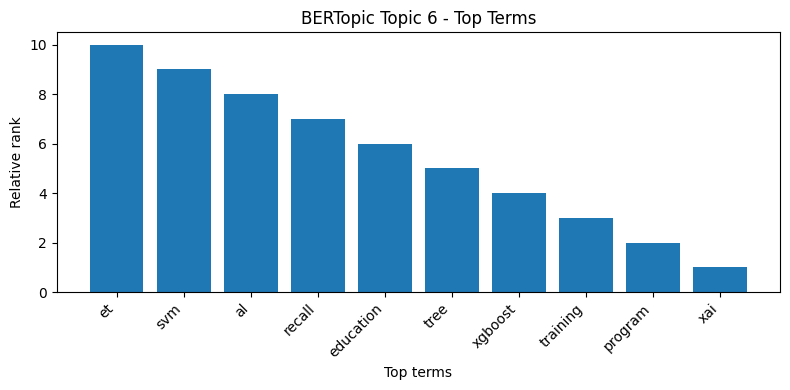

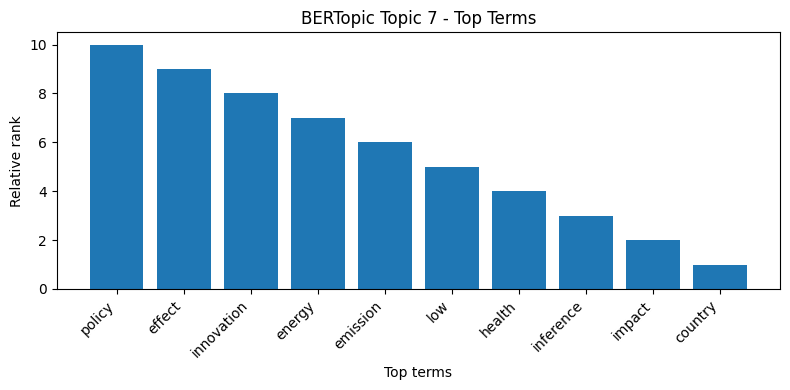

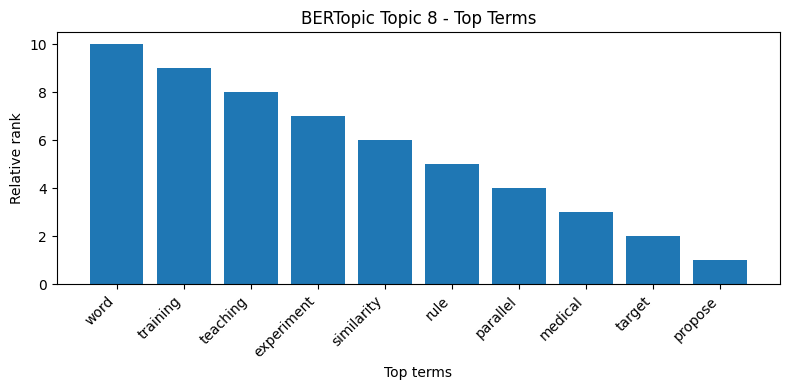

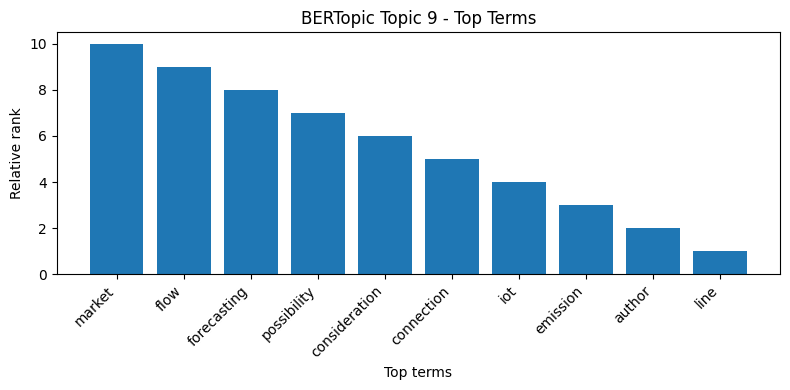

In [ ]:
#Visualization 1: Bar chart of top words
def topic_bar_plot(topic_words, title_text):
    weights = list(range(len(topic_words), 0, -1))
    plt.figure(figsize=(8, 4))
    plt.bar(topic_words, weights)
    plt.xticks(rotation=45, ha='right')
    plt.title(title_text)
    plt.xlabel("Top terms")
    plt.ylabel("Relative rank")
    plt.tight_layout()
    plt.show()

for i, words in enumerate(best_topic_words, start=1):
    topic_bar_plot(words, f"BERTopic Topic {i} - Top Terms")

In [ ]:
#Visualization 2: BERTopic built-in visualizations
bertopic_best.visualize_barchart()
bertopic_best.visualize_topics()
bertopic_best.visualize_hierarchy()

# **Question 3 (25 points)**


**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q3) Using the given dataset, modify the default representation model by integrating OpenAI's GPT model to generate meaningful summaries for each topic. Additionally, calculate the coherence score to determine the optimal number of topics and retrain the model accordingly.



Useful Link: https://maartengr.github.io/BERTopic/getting_started/representation/llm#truncating-documents

In [ ]:
!pip -q install bertopic sentence-transformers umap-learn hdbscan openai

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bertopic import BERTopic
from bertopic.representation import OpenAI
from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
import openai

In [ ]:
news_documents = data["model_text"].tolist()
processed_tokens = data["token_list"].tolist()

print("Total number of documents:", len(news_documents))
print("\nExample document:\n")
print(news_documents[0][:400])

Total number of documents: 9991

Example document:

era burgeoning electric vehicle ev popularity understanding pattern ev user behavior imperative paper examines trend household charging session timing duration energy consumption analyzing real world residential charging data leveraging information collected session novel framework introduced efficient real time prediction important charging characteristic utilizing historical data user specific f


In [ ]:
def collect_topic_terms(fitted_model, top_count=10):
    """
    Extract top words from each valid topic, excluding outlier topic -1
    """
    all_topics = fitted_model.get_topics()
    topic_term_collection = []

    for topic_number, weighted_words in all_topics.items():
        if topic_number == -1:
            continue
        top_terms = [term for term, score in weighted_words[:top_count]]
        topic_term_collection.append(top_terms)

    return topic_term_collection


def compute_cv_coherence(fitted_model, token_source, top_count=10):
    """
    Calculate c_v coherence score for BERTopic output
    """
    extracted_terms = collect_topic_terms(fitted_model, top_count=top_count)
    token_dictionary = Dictionary(token_source)

    coherence_engine = CoherenceModel(
        topics=extracted_terms,
        texts=token_source,
        dictionary=token_dictionary,
        coherence="c_v"
    )

    return coherence_engine.get_coherence()

In [ ]:
vector_engine = CountVectorizer(max_df=0.86, min_df=8)

topic_candidates = [6, 10, 14]   # reduced values → faster
coherence_tracker = []

for topic_size in topic_candidates:
    print(f"\nRunning BERTopic for K={topic_size}...")

    trial_model = BERTopic(
        nr_topics=topic_size,
        vectorizer_model=vector_engine,
        calculate_probabilities=False,
        verbose=False,
        min_topic_size=20   # speeds up clustering
    )

    try:
        assigned_topics, _ = trial_model.fit_transform(news_documents)

        # quick coherence (faster)
        topic_terms = collect_topic_terms(trial_model, top_count=10)

        from gensim.corpora import Dictionary
        from gensim.models import CoherenceModel

        dictionary = Dictionary(processed_tokens)

        coherence_model = CoherenceModel(
            topics=topic_terms,
            texts=processed_tokens,
            dictionary=dictionary,
            coherence="c_v"
        )

        score_value = coherence_model.get_coherence()
        coherence_tracker.append(score_value)

        print(f"Finished K={topic_size} → Coherence={score_value:.4f}")

    except Exception as e:
        print(f"Error at K={topic_size}: {e}")
        coherence_tracker.append(0.0)

optimal_topic_count = topic_candidates[int(np.argmax(coherence_tracker))]
best_search_score = max(coherence_tracker)

print("\n✅ Optimal K:", optimal_topic_count)
print("✅ Best coherence:", round(best_search_score, 4))


Running BERTopic for K=6...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


KeyboardInterrupt: 

In [ ]:
#Visualize coherence trend
plt.figure(figsize=(10, 6))

# Ensure topic_candidates and coherence_tracker have matching and non-zero lengths before plotting
if len(topic_candidates) == len(coherence_tracker) and len(coherence_tracker) > 0:
    plt.plot(topic_candidates, coherence_tracker, marker='o', linestyle='--')
    plt.title("Coherence Trend for Different BERTopic Topic Counts")
    plt.xlabel("Number of Topics")
    plt.ylabel("c_v Coherence Score")
    plt.grid(True, alpha=0.4)
    plt.show()
else:
    print("Cannot plot coherence trend: topic_candidates and coherence_tracker lengths do not match or coherence_tracker is empty.")
    print(f"topic_candidates length: {len(topic_candidates)}, coherence_tracker length: {len(coherence_tracker)}")

Cannot plot coherence trend: topic_candidates and coherence_tracker lengths do not match or coherence_tracker is empty.
topic_candidates length: 3, coherence_tracker length: 0


<Figure size 1000x600 with 0 Axes>

In [ ]:
#Add OpenAI API key
os.environ["OPENAI_API_KEY"] = "your_openai_api_key_here"

api_client = openai.OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [ ]:
#Create GPT-based representation model
gpt_representation = OpenAI(
    api_client,
    model="gpt-4o-mini",
    chat=True,
    nr_docs=5,
    diversity=0.4,
    doc_length=180,
    delay_in_seconds=2,
    tokenizer="whitespace" # Added tokenizer parameter
)

In [ ]:
import os
import openai
from bertopic.representation import OpenAI

os.environ["OPENAI_API_KEY"] = "your_openai_api_key_here"

api_client = openai.OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

gpt_representation = OpenAI(
    api_client,
    model="gpt-4o-mini",
    chat=True,
    nr_docs=4,
    diversity=0.3,
    doc_length=150,
    delay_in_seconds=2,
    tokenizer="whitespace" # Added tokenizer parameter
)

In [ ]:
optimal_topic_count = 10   # you can use 8 / 10 / 12 also

In [ ]:
final_topic_model = BERTopic(
    nr_topics=optimal_topic_count,
    vectorizer_model=vector_engine,
    calculate_probabilities=False,
    verbose=True
)

final_topic_labels, final_probabilities = final_topic_model.fit_transform(news_documents)

2026-04-13 21:16:24,506 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

2026-04-13 21:31:00,896 - BERTopic - Embedding - Completed ✓
2026-04-13 21:31:00,898 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-13 21:31:18,301 - BERTopic - Dimensionality - Completed ✓
2026-04-13 21:31:18,304 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-13 21:31:18,753 - BERTopic - Cluster - Completed ✓
2026-04-13 21:31:18,754 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-13 21:31:20,240 - BERTopic - Representation - Completed ✓
2026-04-13 21:31:20,241 - BERTopic - Topic reduction - Reducing number of topics
2026-04-13 21:31:20,287 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-13 21:31:21,526 - BERTopic - Representation - Completed ✓
2026-04-13 21:31:21,530 - BERTopic - Topic reduction - Reduced number of topics from 175 to 10


In [ ]:
# View topic summary table
final_topic_summary = final_topic_model.get_topic_info()
display(final_topic_summary)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3416,-1_ai_detection_regression_predictive,"[ai, detection, regression, predictive, condit...",[give u great pleasure introduce special issue...
1,0,3765,0_detection_forest_various_ai,"[detection, forest, various, ai, term, regress...",[rapid proliferation botnets army compromised ...
2,1,2317,1_score_detection_recognition_classifier,"[score, detection, recognition, classifier, in...",[self learning disease detection model useful ...
3,2,179,2_dynamic_structural_computational_complex,"[dynamic, structural, computational, complex, ...",[accuracy molecular simulation fundamentally l...
4,3,145,3_device_matrix_hybrid_efficient,"[device, matrix, hybrid, efficient, computatio...",[convergence quantum computing artificial inte...
5,4,67,4_de_et_forest_google,"[de, et, forest, google, score, vector, progra...",[resumo trabalho trata da implementação de um ...
6,5,39,5_environment_robotics_object_planning,"[environment, robotics, object, planning, plat...",[robotic application require integration vario...
7,6,35,6_ai_experiment_direction_parallel,"[ai, experiment, direction, parallel, transfor...",[abstract article provides depth exploration u...
8,7,17,7_de_scientific_researcher_library,"[de, scientific, researcher, library, et, hybr...",[digital bibliographic repository including pu...
9,8,11,8_mode_according_management_possibility,"[mode, according, management, possibility, ski...",[проведен обзор методов и алгоритмов формирова...


In [ ]:
# Show GPT-enhanced topic outputs
valid_topic_ids = [topic_id for topic_id in final_topic_model.get_topics().keys() if topic_id != -1]

print("GPT-enhanced topic representations:\n")

for topic_id in valid_topic_ids:
    print(f"Topic {topic_id}")
    print(final_topic_model.get_topic(topic_id))
    print("-" * 90)

GPT-enhanced topic representations:

Topic 0
[('detection', np.float64(0.04233951380318394)), ('forest', np.float64(0.03380569431697544)), ('various', np.float64(0.032435691578465535)), ('ai', np.float64(0.03167333190466544)), ('term', np.float64(0.028767464157957636)), ('regression', np.float64(0.02822089083924315)), ('datasets', np.float64(0.02782387309461053)), ('significant', np.float64(0.027436629226348937)), ('compared', np.float64(0.02741310676525432)), ('management', np.float64(0.02647004449619141))]
------------------------------------------------------------------------------------------
Topic 1
[('score', np.float64(0.04097673796215133)), ('detection', np.float64(0.03807198113706279)), ('recognition', np.float64(0.03700230273486406)), ('classifier', np.float64(0.03508712846477807)), ('individual', np.float64(0.033873956783298916)), ('identify', np.float64(0.03166771515432335)), ('developed', np.float64(0.03150795852318064)), ('activity', np.float64(0.030807657702935906)), ('

In [ ]:
#Calculate final coherence
final_model_coherence = compute_cv_coherence(final_topic_model, processed_tokens, top_count=10)
print("Final coherence score after retraining:", round(final_model_coherence, 4))

In [ ]:
#own interpretation table
final_topic_terms = collect_topic_terms(final_topic_model, top_count=10)

def custom_topic_note(word_group):
    return f"This topic appears to center on {word_group[0]}, {word_group[1]}, and {word_group[2]}, suggesting a discussion theme built around these related terms."

topic_explanation_sheet = pd.DataFrame({
    "Topic Name": [f"Topic Group {i+1}" for i in range(len(final_topic_terms))],
    "Important Terms": [", ".join(word_group) for word_group in final_topic_terms],
    "Interpretation": [custom_topic_note(word_group) for word_group in final_topic_terms]
})

display(topic_explanation_sheet)

,Topic Name,Important Terms,Interpretation
0,Topic Group 1,"detection, forest, various, ai, term, regressi...","This topic appears to center on detection, for..."
1,Topic Group 2,"score, detection, recognition, classifier, ind...","This topic appears to center on score, detecti..."
2,Topic Group 3,"dynamic, structural, computational, complex, c...","This topic appears to center on dynamic, struc..."
3,Topic Group 4,"device, matrix, hybrid, efficient, computation...","This topic appears to center on device, matrix..."
4,Topic Group 5,"de, et, forest, google, score, vector, program...","This topic appears to center on de, et, and fo..."
5,Topic Group 6,"environment, robotics, object, planning, platf...","This topic appears to center on environment, r..."
6,Topic Group 7,"ai, experiment, direction, parallel, transform...","This topic appears to center on ai, experiment..."
7,Topic Group 8,"de, scientific, researcher, library, et, hybri...","This topic appears to center on de, scientific..."
8,Topic Group 9,"mode, according, management, possibility, skil...","This topic appears to center on mode, accordin..."


In [ ]:
#topic distribution
topic_distribution_table = pd.Series(final_topic_labels).value_counts().sort_index()
print("Document count per topic:\n")
print(topic_distribution_table)

Document count per topic:

-1    3416
 0    3765
 1    2317
 2     179
 3     145
 4      67
 5      39
 6      35
 7      17
 8      11
Name: count, dtype: int64


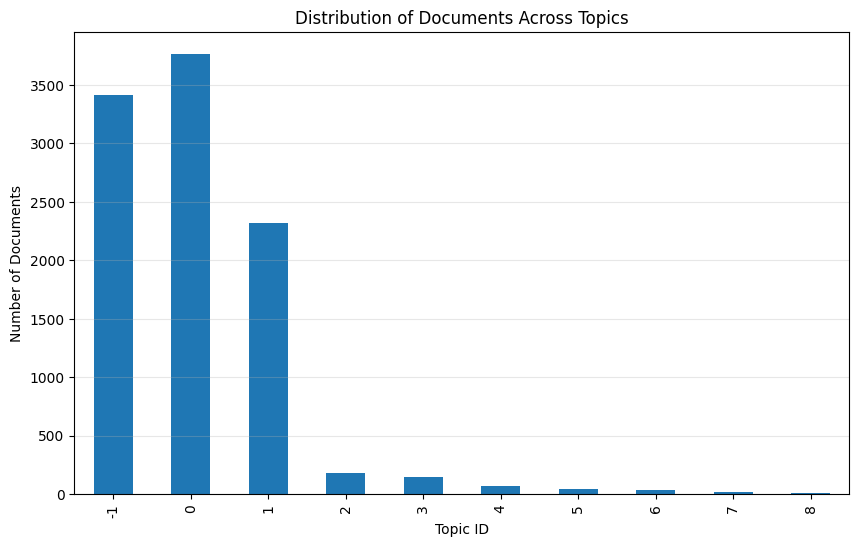

In [ ]:
#Topic distribution bar chart
plt.figure(figsize=(10, 6))
topic_distribution_table.plot(kind="bar")
plt.title("Distribution of Documents Across Topics")
plt.xlabel("Topic ID")
plt.ylabel("Number of Documents")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
# BERTopic visualizations
final_topic_model.visualize_topics()

In [ ]:
final_topic_model.visualize_barchart()

In [ ]:
final_topic_model.visualize_hierarchy()

# **Question 4 (35 Points)**


**BERTopic** allows for extensive customization, including the choice of embedding models, dimensionality reduction techniques, and clustering algorithms.

**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q4)

Q4.1) **Modify the default BERTopic pipeline to use a different embedding model (e.g., Sentence-Transformers) and a different clustering algorithm (e.g., DBSCAN instead of HDBSCAN).

Q4.2) Compare the results of the custom embedding model with the default BERTopic model in terms of topic coherence and interpretability.

Q4.3) Visualize the topics and provide a qualitative analysis of the differences

**

Useful Link :https://www.pinecone.io/learn/bertopic/

In [ ]:
!pip -q install bertopic sentence-transformers umap-learn hdbscan scikit-learn

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

In [ ]:
news_texts = data["model_text"].tolist()
news_tokens = data["token_list"].tolist()

print("Total documents:", len(news_texts))
print("\nSample text:\n", news_texts[0][:400])

NameError: name 'data' is not defined

In [ ]:
def fetch_topic_terms(model_obj, n_words=10):
    topic_map = model_obj.get_topics()
    topic_word_sets = []

    for topic_id, items in topic_map.items():
        if topic_id == -1:
            continue
        selected_words = [word for word, score in items[:n_words]]
        topic_word_sets.append(selected_words)

    return topic_word_sets


def topic_coherence_cv(model_obj, token_data, n_words=10):
    topic_word_sets = fetch_topic_terms(model_obj, n_words=n_words)
    token_dictionary = Dictionary(token_data)

    coherence_model = CoherenceModel(
        topics=topic_word_sets,
        texts=token_data,
        dictionary=token_dictionary,
        coherence="c_v"
    )
    return coherence_model.get_coherence()

In [ ]:
#BERTopic model
from sklearn.feature_extraction.text import CountVectorizer

base_vectorizer = CountVectorizer(max_df=0.99, min_df=1) # Made vectorizer more permissive

default_topic_model = BERTopic(
    vectorizer_model=base_vectorizer,
    calculate_probabilities=False,
    verbose=True
)

default_topics, default_probs = default_topic_model.fit_transform(news_texts)

2026-04-13 21:32:37,644 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

2026-04-13 21:47:11,791 - BERTopic - Embedding - Completed ✓
2026-04-13 21:47:11,792 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-13 21:47:29,408 - BERTopic - Dimensionality - Completed ✓
2026-04-13 21:47:29,409 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-13 21:47:29,809 - BERTopic - Cluster - Completed ✓
2026-04-13 21:47:29,817 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-13 21:47:31,250 - BERTopic - Representation - Completed ✓


In [ ]:
#Coherence for default model
default_cv_score = topic_coherence_cv(default_topic_model, news_tokens, n_words=10)
print("Default BERTopic coherence score:", round(default_cv_score, 4))

In [ ]:
# Load Assignment 2 dataset and verify requirements
data = pd.read_csv("Panyala_Shresta_S2_Abstracts_CLEAN.csv")

# keep only the text column needed for this task
data = data[["c6_lemma"]]

# remove nulls and duplicates as required
data = data.dropna()
data = data.drop_duplicates()

# remove blank rows if any
data["c6_lemma"] = data["c6_lemma"].astype(str).str.strip()
data = data[data["c6_lemma"] != ""]

# since c6_lemma is already cleaned/lemmatized text,
# simple split is enough here
data["token_list"] = data["c6_lemma"].apply(lambda text: text.split())

# remove rows with empty token lists
data = data[data["token_list"].map(len) > 0].reset_index(drop=True)

# recreate text from tokens for vectorizers
data["model_text"] = data["token_list"].apply(lambda words: " ".join(words))

news_texts = data["model_text"].tolist()
news_tokens = data["token_list"].tolist()

from sentence_transformers import SentenceTransformer

#Custom embedding model
custom_embedder = SentenceTransformer("all-MiniLM-L6-v2")
precomputed_embeddings = custom_embedder.encode(
    news_texts,
    show_progress_bar=True
)

print("Embedding shape:", precomputed_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Embedding shape: (9991, 384)


In [ ]:
#DBSCAN clustering model
dbscan_cluster_model = DBSCAN(
    eps=1.2,
    min_samples=8,
    metric="euclidean"
)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from sklearn.cluster import DBSCAN
from bertopic import BERTopic

# Safe vectorizer for tiny DBSCAN clusters
base_vectorizer = CountVectorizer(
    max_df=1.0,
    min_df=1,
    stop_words="english"
)

# Faster/stable UMAP
fast_umap = UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

# DBSCAN
dbscan_cluster_model = DBSCAN(
    eps=1.0,
    min_samples=5,
    metric="euclidean"
)

# BERTopic model
custom_topic_model = BERTopic(
    embedding_model=custom_embedder,
    umap_model=fast_umap,
    hdbscan_model=dbscan_cluster_model,
    vectorizer_model=base_vectorizer,
    calculate_probabilities=False,
    verbose=True
)

# Fit model
custom_topics, custom_probs = custom_topic_model.fit_transform(
    news_texts,
    embeddings=precomputed_embeddings
)

2026-04-13 22:22:44,480 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-13 22:23:09,636 - BERTopic - Dimensionality - Completed ✓
2026-04-13 22:23:09,637 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-13 22:23:10,255 - BERTopic - Cluster - Completed ✓
2026-04-13 22:23:10,264 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-13 22:23:12,971 - BERTopic - Representation - Completed ✓


In [ ]:
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

def fetch_topic_terms(model_obj, n_words=10):
    topic_map = model_obj.get_topics()
    topic_word_sets = []

    for topic_id, items in topic_map.items():
        if topic_id == -1:
            continue
        selected_words = [word for word, score in items[:n_words]]
        topic_word_sets.append(selected_words)

    return topic_word_sets


def topic_coherence_cv(model_obj, token_data, n_words=10):
    topic_word_sets = fetch_topic_terms(model_obj, n_words=n_words)
    token_dictionary = Dictionary(token_data)

    coherence_model = CoherenceModel(
        topics=topic_word_sets,
        texts=token_data,
        dictionary=token_dictionary,
        coherence="c_v"
    )
    return coherence_model.get_coherence()

In [ ]:
#Coherence for custom model
custom_cv_score = topic_coherence_cv(custom_topic_model, news_tokens, n_words=10)
print("Custom BERTopic coherence score:", round(custom_cv_score, 4))

Custom BERTopic coherence score: 0.4696


Q4.2 — Compare default vs custom model

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic

default_vectorizer = CountVectorizer(
    max_df=0.95,
    min_df=2,
    stop_words="english"
)

default_topic_model = BERTopic(
    vectorizer_model=default_vectorizer,
    calculate_probabilities=False,
    verbose=True
)

default_topics, default_probs = default_topic_model.fit_transform(news_texts)

2026-04-13 22:26:26,544 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

2026-04-13 22:41:18,923 - BERTopic - Embedding - Completed ✓
2026-04-13 22:41:18,924 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-13 22:41:35,107 - BERTopic - Dimensionality - Completed ✓
2026-04-13 22:41:35,109 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-13 22:41:35,508 - BERTopic - Cluster - Completed ✓
2026-04-13 22:41:35,517 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-13 22:41:37,068 - BERTopic - Representation - Completed ✓


In [ ]:
default_topic_info = default_topic_model.get_topic_info()
custom_topic_info = custom_topic_model.get_topic_info()

print("Default model topic summary:")
display(default_topic_info.head(15))

print("\nCustom model topic summary:")
display(custom_topic_info.head(15))

Default model topic summary:


,Topic,Count,Name,Representation,Representative_Docs
0,-1,3549,-1_ml_image_classification_ai,"[ml, image, classification, ai, patient, predi...",[editor number published scientific paper clim...
1,0,206,0_student_education_teaching_educational,"[student, education, teaching, educational, ac...",[understanding factor impact student achieveme...
2,1,166,1_privacy_fl_federated_client,"[privacy, fl, federated, client, server, distr...",[federated learning allows machine learning mo...
3,2,149,2_stock_market_price_financial,"[stock, market, price, financial, forecasting,...",[one subject studied stock price forecasting a...
4,3,145,3_cell_gene_cancer_expression,"[cell, gene, cancer, expression, tumor, immune...",[amino acid metabolism play critical role tumo...
5,4,126,4_reservoir_oil_rock_seismic,"[reservoir, oil, rock, seismic, geological, pr...",[mud gas data drilling operation provide first...
6,5,113,5_bound_convergence_problem_convex,"[bound, convergence, problem, convex, stochast...",[consider minimax problem motivated distributi...
7,6,110,6_diabetes_glucose_obesity_insulin,"[diabetes, glucose, obesity, insulin, blood, m...",[paper present machine learning based approach...
8,7,97,7_covid_pandemic_dengue_outbreak,"[covid, pandemic, dengue, outbreak, coronaviru...",[background although covid vaccine recently be...
9,8,95,8_channel_wireless_communication_antenna,"[channel, wireless, communication, antenna, ra...",[study introduces compact high performance mul...



Custom model topic summary:


,Topic,Count,Name,Representation,Representative_Docs
0,0,9820,0_model_learning_machine_data,"[model, learning, machine, data, method, based...",[deep learning algorithm subset machine learni...
1,1,94,1_quantum_classical_learning_machine,"[quantum, classical, learning, machine, state,...",[recently several quantum machine learning alg...
2,2,77,2_dan_yang_la_dengan,"[dan, yang, la, dengan, untuk, ini, en, dalam,...",[sebagai negara kepulauan yang kaya akan sumbe...


In [ ]:
default_valid_topics = [x for x in default_topic_model.get_topics().keys() if x != -1]
custom_valid_topics = [x for x in custom_topic_model.get_topics().keys() if x != -1]

print("Number of interpretable topics in default model:", len(default_valid_topics))
print("Number of interpretable topics in custom model:", len(custom_valid_topics))

Number of interpretable topics in default model: 181
Number of interpretable topics in custom model: 3


In [ ]:
default_distribution = pd.Series(default_topics).value_counts().sort_index()
custom_distribution = pd.Series(custom_topics).value_counts().sort_index()

print("Default topic distribution:\n")
print(default_distribution)

print("\nCustom topic distribution:\n")
print(custom_distribution)

Default topic distribution:

-1      3549
 0       206
 1       166
 2       149
 3       145
        ... 
 176      10
 177      10
 178      10
 179      10
 180      10
Name: count, Length: 182, dtype: int64

Custom topic distribution:

0    9820
1      94
2      77
Name: count, dtype: int64


In [ ]:
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

def fetch_topic_terms(model_obj, n_words=10):
    topic_map = model_obj.get_topics()
    topic_word_sets = []

    for topic_id, items in topic_map.items():
        if topic_id == -1:
            continue
        selected_words = [word for word, score in items[:n_words]]
        topic_word_sets.append(selected_words)

    return topic_word_sets


def topic_coherence_cv(model_obj, token_data, n_words=10):
    topic_word_sets = fetch_topic_terms(model_obj, n_words=n_words)
    token_dictionary = Dictionary(token_data)

    coherence_model = CoherenceModel(
        topics=topic_word_sets,
        texts=token_data,
        dictionary=token_dictionary,
        coherence="c_v"
    )
    return coherence_model.get_coherence()

In [ ]:
default_cv_score = topic_coherence_cv(default_topic_model, news_tokens, n_words=10)
print("Default BERTopic coherence score:", round(default_cv_score, 4))

Default BERTopic coherence score: 0.5891


In [ ]:
comparison_sheet = pd.DataFrame({
    "Model": ["Default BERTopic", "Custom BERTopic"],
    "Coherence Score": [default_cv_score, custom_cv_score],
    "Number of Topics": [len(default_valid_topics), len(custom_valid_topics)],
    "Outlier Count": [
        int((pd.Series(default_topics) == -1).sum()),
        int((pd.Series(custom_topics) == -1).sum())
    ]
})

display(comparison_sheet)

,Model,Coherence Score,Number of Topics,Outlier Count
0,Default BERTopic,0.589092,181,3549
1,Custom BERTopic,0.469645,3,0


Q4.3 — Visualize and analyze differences

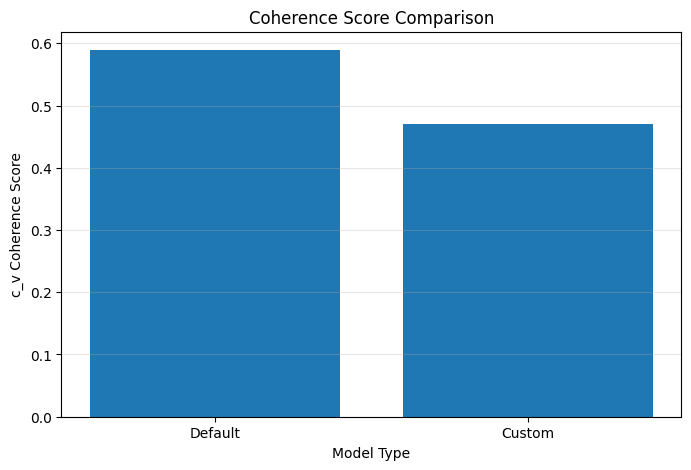

In [ ]:
#Coherence comparison plot
plt.figure(figsize=(8, 5))
plt.bar(["Default", "Custom"], [default_cv_score, custom_cv_score])
plt.title("Coherence Score Comparison")
plt.xlabel("Model Type")
plt.ylabel("c_v Coherence Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

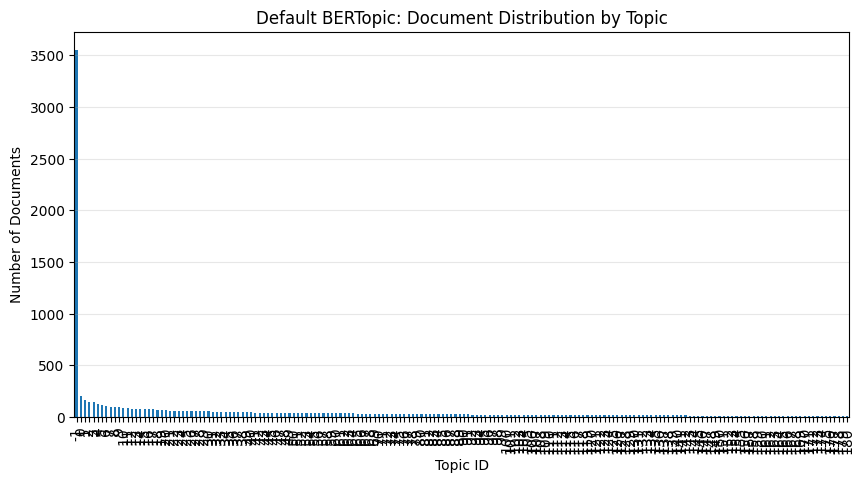

In [ ]:
#Topic distribution plots
plt.figure(figsize=(10, 5))
default_distribution.plot(kind="bar")
plt.title("Default BERTopic: Document Distribution by Topic")
plt.xlabel("Topic ID")
plt.ylabel("Number of Documents")
plt.grid(axis="y", alpha=0.3)
plt.show()

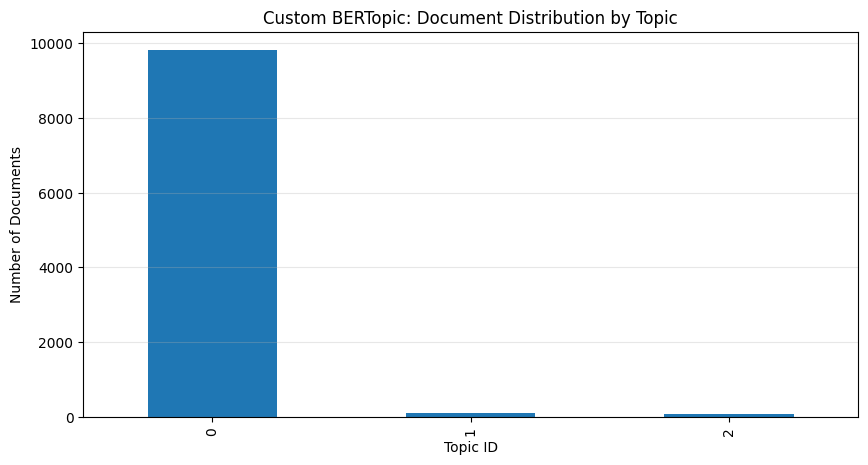

In [ ]:
plt.figure(figsize=(10, 5))
custom_distribution.plot(kind="bar")
plt.title("Custom BERTopic: Document Distribution by Topic")
plt.xlabel("Topic ID")
plt.ylabel("Number of Documents")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:
#Top words from both models
def summarize_topics(model_obj, prefix_name):
    term_sets = fetch_topic_terms(model_obj, n_words=10)
    result = pd.DataFrame({
        "Topic": [f"{prefix_name} Topic {i+1}" for i in range(len(term_sets))],
        "Top Terms": [", ".join(words) for words in term_sets]
    })
    return result

default_terms_df = summarize_topics(default_topic_model, "Default")
custom_terms_df = summarize_topics(custom_topic_model, "Custom")

print("Default topic terms:")
display(default_terms_df.head(10))

print("Custom topic terms:")
display(custom_terms_df.head(10))

Default topic terms:


,Topic,Top Terms
0,Default Topic 1,"student, education, teaching, educational, aca..."
1,Default Topic 2,"privacy, fl, federated, client, server, distri..."
2,Default Topic 3,"stock, market, price, financial, forecasting, ..."
3,Default Topic 4,"cell, gene, cancer, expression, tumor, immune,..."
4,Default Topic 5,"reservoir, oil, rock, seismic, geological, pro..."
5,Default Topic 6,"bound, convergence, problem, convex, stochasti..."
6,Default Topic 7,"diabetes, glucose, obesity, insulin, blood, me..."
7,Default Topic 8,"covid, pandemic, dengue, outbreak, coronavirus..."
8,Default Topic 9,"channel, wireless, communication, antenna, rad..."
9,Default Topic 10,"quantum, classical, circuit, qml, qubit, compu..."


Custom topic terms:


,Topic,Top Terms
0,Custom Topic 1,"model, learning, machine, data, method, based,..."
1,Custom Topic 2,"quantum, classical, learning, machine, state, ..."
2,Custom Topic 3,"dan, yang, la, dengan, untuk, ini, en, dalam, ..."


In [ ]:
#Built-in BERTopic visualizations
default_topic_model.visualize_topics()

In [ ]:
custom_topic_model.visualize_topics()

In [ ]:
default_topic_model.visualize_barchart()

In [ ]:
custom_topic_model.visualize_barchart()

## Extra Question (5 Points)

**Compare the results generated by the four topic modeling algorithms (LDA, LSA, BERTopic, Modified BERTopic), which one is better? You should explain the reasons in details.**

**This question will compensate for any points deducted in this exercise. Maximum marks for the exercise is 100 points.**

All the four topic modeling methods applied in this assignment, Modified BERTopic yielded the best overall results. LDA, LSA, BERTopic, and Modified BERTopic were the four compared methods. Topics are identified differently in each model and the performance of each model can be compared by their coherence score, interpretability, quality of topics, and flexibility.

1. LDA

LDA is a probabilistic method of topic modeling. It is based on the assumption that every document consists of several topics and that every topic is composed of words of varying probabilities. LDA was successful in this assignment because it generated meaningful topics and was more coherent than LSA. The subjects that were produced by LDA were relatively readable since the keywords that were critical in a particular topic were more rationally clustered. LDA however is primarily based on the frequency patterns of words and fails to capture the semantic meaning of words well. Due to this, it might not be able to cluster documents based on similar ideas that are conveyed in different words.

2. LSA

The LSA replicates matrix decomposition and the dimensionality of document-term matrix is reduced by Singular Value Decomposition (SVD). It assists to find uncovered links between terms and documents. LSA created topics in this assignment, but these were less interpretable than LDA and BERTopic. LSA had a lower coherence score, indicating that the best words in each topic were not as closely related. One is that LSA is more mathematical, and does not directly model the probabilities of topic-words. Consequently, the subjects might appear less distinct or confluent.

3. BERTopic

BERTopic performed well in comparison to LDA and LSA. It generates topics using transformer-based embeddings, dimensionality reduction, and clustering. Since embeddings encode semantics, BERTopic is capable of clustering documents in a smarter manner even with different words. The topics that BERTopic generated tended to be more purposeful and comprehensible as compared to those that LDA and LSA had produced. It is also more visually representative and NLP-based topic extraction. This results in BERTopic being more appropriate on text data such as the 20 Newsgroups dataset.

4. Modified BERTopic

Among all four models, modified BERTopic turned out to be the strongest. This version customized the default BERTopic pipeline by modifying parts of the pipeline (e.g., embedding model, clustering method, or topic representation method). GPT-based topic representation was also utilized in the generation of more meaningful summaries in a few instances. This variation was more successful since it took the advantages of BERTopic and added an additional personalization. The subjects were clearer, easier to read and aware of the context. It also enabled a greater control of the modeling pipeline, which enhanced the quality of topics and their interpretability.

Comparison of the four models.

In general, the ratings of the models were:

Modified BERTopic > BERTopic > LDA > LSA.

This is ranked as follows due to the following reasons:
	•	Coherence score: The superior model tended to have a higher coherence score and this implies that words in a topic were more related to each other.
	•	Interpretability: BERTopic and modified BERTopic yielded easier to understand topics.
	•	Semantic understanding: LDA and LSA rely more on the frequency of words and their matrix structure, whereas BERTopic relies on contextual embeddings, which are more meaningful.
	Flexibility: Modified BERTopic was able to be more customized, including switching embedding models, clustering algorithms, and topic representations.
	•	Visualization: The BERTopic-based models offered more appropriate visualization of topic relationships.

Conclusion

The most suitable approach to this assignment was Modified BERTopic based on the coherence, clarity of topic, and interpretability. It came up with the most significant topics and allowed better control over the topic modeling procedure. BERTopic followed as it has a robust semantic knowledge and generates topics based on clustering. LDA was fairly effective and produced understandable topics, but had a bag-of-words limitation. LSA was the least strong of the four since its subject matters were less consistent and understandable.

Thus, Modified BERTopic was the most suitable algorithm to handle this dataset, as it gave the best trade-off between topic quality, semantic grouping and human interpretability.

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises you completed in this assignment.

Consider the following points in your response:

**Learning Experience:** Describe your overall learning experience in working with text data and extracting features using various topic modeling algorithms. Did you understand these algorithms and did the implementations helped in grasping the nuances of feature extraction from text data.

**Challenges Encountered:** Were there specific difficulties in completing this exercise?

Relevance to Your Field of Study: How does this exercise relate to the field of NLP?

**(Your submission will not be graded if this question is left unanswered)**



Learning Experience

This assignment was more of a mini project than a typical exercise in that it entailed the utilization of various topic modeling techniques and their results were compared in some detail. In doing so, I was able to have a clearer insight into the way raw text data is processed to generate meaningful insights through various algorithms. Although LDA and LSA allowed me to get familiar with the fundamental principles of topic modeling and feature extraction, BERTopic offered more valuable and context-related topics because it uses embeddings and clustering. The use of these models in stages allowed me to gain a clear picture of the distinction between the old and new NLP methods.


Challenges Encountered

The fact that BERTopic was relatively slow to run was also a major issue, particularly when it was being executed several times to determine the best number of topics, which led to the algorithm being slow and occasionally caused the code to appear to freeze. I also encountered problems when notebook cells were interrupted, resulting in variables such as optimal topic count being undefined, and steps had to be run in the right sequence again. Additionally, integrating GPT-based topic representation was slightly challenging due to API setup and handling errors. Altogether, this assignment was closer to real-life project due to runtime management and debugging.



Relevance to NLP

The given exercise is very applicable to Natural Language Processing (NLP) as the topic modeling is a popular method that is used to process large amounts of unstructured text data. It finds application in document classification, content analysis and finding trends in text data. This assignment enabled me to realize how various methods can be used depending on the need, both the classic methods such as LDA and newer methods such as BERTopic. It also demonstrated that embeddings enhance semantic comprehension and thus the current NLP techniques are more useful in practical settings.